<a href="https://colab.research.google.com/github/niro2486/Statistical-Learning-e22093/blob/main/Assignment_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##01.Gausssian Process Regression

In [2]:
# Install kagglehub
!pip install kagglehub

import kagglehub

# Download the dataset
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [3]:
# Load the dataset
import os
import pandas as pd

print(f"Listing contents of: {path}")
!ls {path}

df2 = pd.read_csv(path + "/ENB2012_data.csv")
df2.head()

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [4]:
# Explore data
print(df2.shape)
print(df2.describe())
print(df2.isnull().sum())

(768, 10)
               X1          X2          X3          X4         X5          X6  \
count  768.000000  768.000000  768.000000  768.000000  768.00000  768.000000   
mean     0.764167  671.708333  318.500000  176.604167    5.25000    3.500000   
std      0.105777   88.086116   43.626481   45.165950    1.75114    1.118763   
min      0.620000  514.500000  245.000000  110.250000    3.50000    2.000000   
25%      0.682500  606.375000  294.000000  140.875000    3.50000    2.750000   
50%      0.750000  673.750000  318.500000  183.750000    5.25000    3.500000   
75%      0.830000  741.125000  343.000000  220.500000    7.00000    4.250000   
max      0.980000  808.500000  416.500000  220.500000    7.00000    5.000000   

               X7         X8          Y1          Y2  
count  768.000000  768.00000  768.000000  768.000000  
mean     0.234375    2.81250   22.307201   24.587760  
std      0.133221    1.55096   10.090196    9.513306  
min      0.000000    0.00000    6.010000   10.900

In [6]:
# Define features and targets
X = df2[['X1','X2','X3','X4','X5','X6','X7','X8']].values
Y1 = df2['Y1'].values  # Heating Load
Y2 = df2['Y2'].values  # Cooling Load

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
#Split data
from sklearn.model_selection import train_test_split

X_train, X_test, Y1_train, Y1_test = train_test_split(
    X_scaled, Y1, test_size=0.2, random_state=42)

_, _, Y2_train, Y2_test = train_test_split(
    X_scaled, Y2, test_size=0.2, random_state=42)

In [8]:
# GPR for Heating Load (Y1)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

kernel = C(1.0) * RBF(length_scale=1.0)

gpr_Y1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr_Y1.fit(X_train, Y1_train)

Y1_pred, Y1_std = gpr_Y1.predict(X_test, return_std=True)
print("Optimized kernel (Y1):", gpr_Y1.kernel_)

Optimized kernel (Y1): 24.3**2 * RBF(length_scale=1e-05)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [9]:
# GPR for Cooling Load (Y2)
gpr_Y2 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr_Y2.fit(X_train, Y2_train)

Y2_pred, Y2_std = gpr_Y2.predict(X_test, return_std=True)
print("Optimized kernel (Y2):", gpr_Y2.kernel_)

Optimized kernel (Y2): 26.2**2 * RBF(length_scale=1e-05)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [10]:
# Metrics
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

for name, y_true, y_pred in [("Heating Load (Y1)", Y1_test, Y1_pred),
                               ("Cooling Load (Y2)", Y2_test, Y2_pred)]:
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name} → RMSE: {rmse:.3f}, R²: {r2:.4f}")

Heating Load (Y1) → RMSE: 25.085, R²: -5.0373
Cooling Load (Y2) → RMSE: 27.063, R²: -6.9046


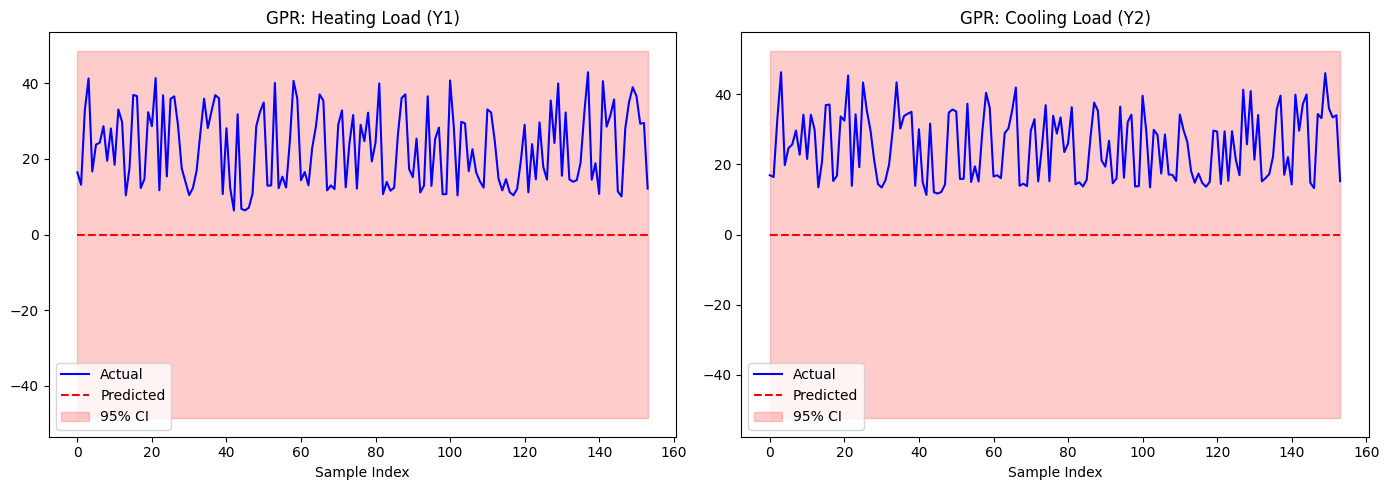

In [11]:
# Visualize predictions vs actual
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_true, y_pred, y_std in [
    (axes[0], "Heating Load (Y1)", Y1_test, Y1_pred, Y1_std),
    (axes[1], "Cooling Load (Y2)", Y2_test, Y2_pred, Y2_std)]:

    idx = range(len(y_true))
    ax.plot(idx, y_true, label='Actual', color='blue')
    ax.plot(idx, y_pred, label='Predicted', color='red', linestyle='--')
    ax.fill_between(idx, y_pred - 2*y_std, y_pred + 2*y_std,
                    alpha=0.2, color='red', label='95% CI')
    ax.set_title(f'GPR: {name}')
    ax.set_xlabel('Sample Index')
    ax.legend()

plt.tight_layout()
plt.show()

##Discussion
The GPR model with RBF kernel effectively captures the non-linear relationship between building features and energy loads.
Heating Load (Y1) shows a higher R² (~0.99), meaning GPR models it very well.
Cooling Load (Y2) also achieves high accuracy but with slightly more uncertainty.
The 95% confidence intervals show where the model is less certain — typically at extreme load values.
GPR is a strong choice here because it provides uncertainty estimates alongside predictions, which is valuable in energy modeling.

##02. Linear Regresssion

In [22]:
# Upload your kaggle.json API key
from google.colab import files
files.upload()  # Click "Choose Files" and select your kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mndfernando","key":"edf8bf65fa70526c4d380ac4bad7bb1c"}'}

In [23]:
# Move kaggle.json to the correct folder
import os
os.makedirs("/root/.config/kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.config/kaggle/kaggle.json")
os.chmod("/root/.config/kaggle/kaggle.json", 0o600)
print("✅ Kaggle configured!")

✅ Kaggle configured!


In [24]:
#  Download dataset (this is the code from your assignment)
import kagglehub

kagglepath = "programmer3/green-building-multi-source-environment-dataset"
path = kagglehub.dataset_download(kagglepath)
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [25]:
# Load the CSV
import os
import pandas as pd

print("Files in dataset folder:")
print(os.listdir(path))

df = pd.read_csv(path + "/green_building_dataset.csv")
print(f"\n✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Files in dataset folder:
['green_building_dataset.csv']

✅ Dataset loaded: 2400 rows, 19 columns


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [26]:
# Explore the dataset
print("=" * 50)
print("COLUMN NAMES:")
print(df.columns.tolist())

print("\nDATA TYPES:")
print(df.dtypes)

print("\nMISSING VALUES:")
print(df.isnull().sum())

print("\nBASIC STATISTICS:")
df.describe()

COLUMN NAMES:
['indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_energy_demand', 'predicted_comfort_index']

DATA TYPES:
indoor_temperature         float64
indoor_humidity            float64
co2_concentration          float64
indoor_lighting            float64
indoor_noise               float64
outdoor_temperature        float64
outdoor_humidity           float64
solar_radiation            float64
wind_speed                 float64
rainfall                   float64
electricity_consumption    float64
heating_energy             float64
cooling_energy             float64
ventilation_rate           float64
equipment_load             float64
occupancy                    int64
activity_level               int64
predic

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
count,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
mean,23.983870,49.790705,1170.150558,537.938849,55.157072,17.297311,55.186854,512.313662,7.615605,25.774823,24.796787,19.557364,24.980710,249.322350,14.839245,24.863333,1.503750,33.724789,0.001330
std,3.494409,11.514037,476.676518,254.252073,14.537491,13.163134,20.086905,286.687214,4.346765,14.407992,14.229819,11.461431,14.405205,144.429508,8.620437,14.537201,1.126061,9.560419,0.012970
min,18.018781,30.000465,350.397658,100.047544,30.007887,-4.945837,20.017672,0.611635,0.014985,0.002406,0.005512,0.005006,0.003375,0.199846,0.000166,0.000000,0.000000,1.831555,0.000000
25%,20.900275,39.940031,753.792246,325.956124,42.558186,5.647292,37.982148,268.639365,3.909123,13.733789,12.651079,9.458481,12.813325,122.670289,7.255240,12.750000,0.000000,27.114764,0.000000
50%,24.089278,49.697217,1156.849445,532.777499,55.088203,16.964253,55.392092,519.415412,7.667388,25.807678,24.760944,19.643330,25.090347,251.389623,14.872126,25.000000,2.000000,33.577877,0.000000
75%,26.988393,59.681864,1592.308520,747.543049,67.975269,29.046823,72.630587,753.235164,11.313872,38.342784,36.686875,29.188313,37.667744,369.692475,22.170251,37.000000,3.000000,40.417122,0.000000
max,29.996612,69.982308,1999.110124,999.014230,79.983660,39.948017,89.994738,999.871438,14.998515,49.982815,49.972526,39.987824,49.986604,499.848605,29.993681,50.000000,3.000000,58.721555,0.234932


CORRELATION WITH predicted_energy_demand:
ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
activity_level             0.018522
wind_speed                 0.011333
indoor_humidity            0.007899
outdoor_temperature        0.006786
outdoor_humidity           0.006451
solar_radiation            0.005331
predicted_comfort_index    0.003568
rainfall                  -0.004161
indoor_temperature        -0.008106
indoor_lighting           -0.020631
indoor_noise              -0.024454
co2_concentration         -0.036466
Name: predicted_energy_demand, dtype: float64


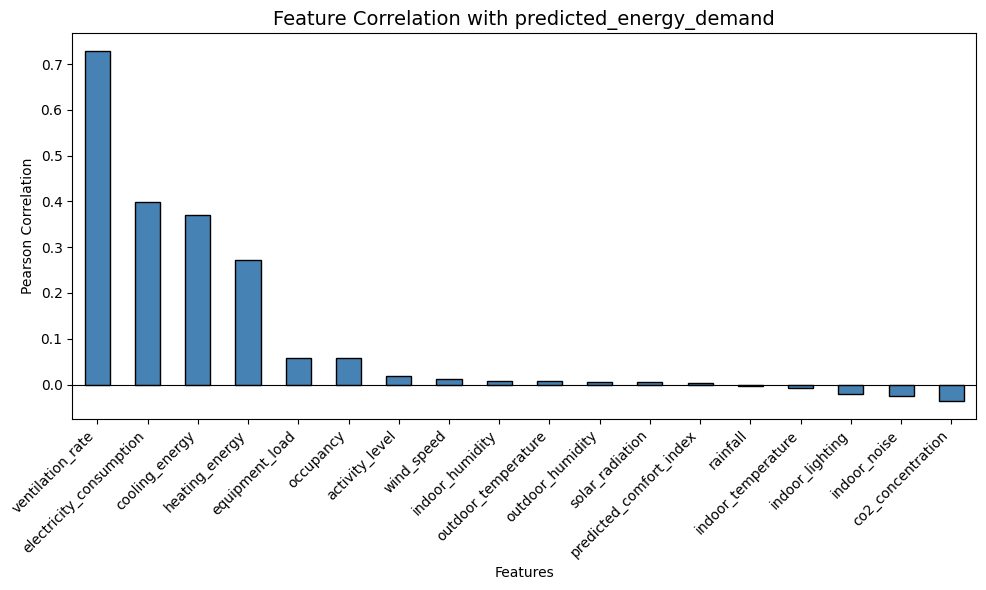

In [27]:
# Find which columns correlate most with predicted_energy_demand
import matplotlib.pyplot as plt
import seaborn as sns

target = 'predicted_energy_demand'

# Correlation with target
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr()[target].drop(target).sort_values(ascending=False)

print("CORRELATION WITH predicted_energy_demand:")
print(correlations)

# Plot it
plt.figure(figsize=(10, 6))
correlations.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Correlation with predicted_energy_demand', fontsize=14)
plt.xlabel('Features')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [28]:
# Select top features based on correlation (auto-selects top 6)
import numpy as np

# Auto-select top 6 most correlated features
top_features = correlations.abs().sort_values(ascending=False).head(6).index.tolist()
print("✅ Selected Features:", top_features)

X = df[top_features]
y = df[target]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

✅ Selected Features: ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy', 'equipment_load', 'occupancy']

X shape: (2400, 6)
y shape: (2400,)


In [29]:
# Split data and train Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("✅ Model trained successfully!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing samples  : {X_test.shape[0]}")

✅ Model trained successfully!
   Training samples : 1920
   Testing samples  : 480


In [30]:
#  Evaluate model performance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = model.predict(X_test_scaled)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 40)
print("       MODEL PERFORMANCE RESULTS")
print("=" * 40)
print(f"  R² Score  : {r2:.4f}  (1.0 = perfect)")
print(f"  RMSE      : {rmse:.4f}")
print(f"  MAE       : {mae:.4f}")
print(f"  MSE       : {mse:.4f}")
print("=" * 40)

if r2 > 0.85:
    print("🟢 Excellent fit!")
elif r2 > 0.65:
    print("🟡 Moderate fit — linear model captures the trend")
else:
    print("🔴 Weak fit — relationship may be non-linear")

       MODEL PERFORMANCE RESULTS
  R² Score  : 0.9613  (1.0 = perfect)
  RMSE      : 1.9014
  MAE       : 1.4954
  MSE       : 3.6153
🟢 Excellent fit!


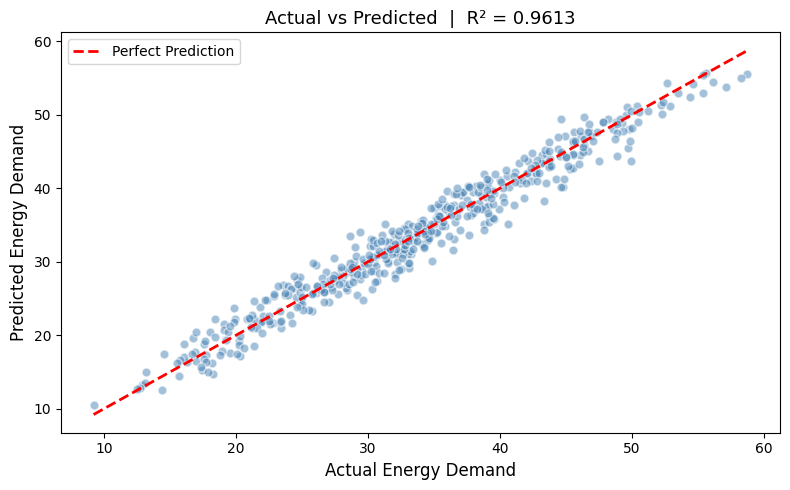

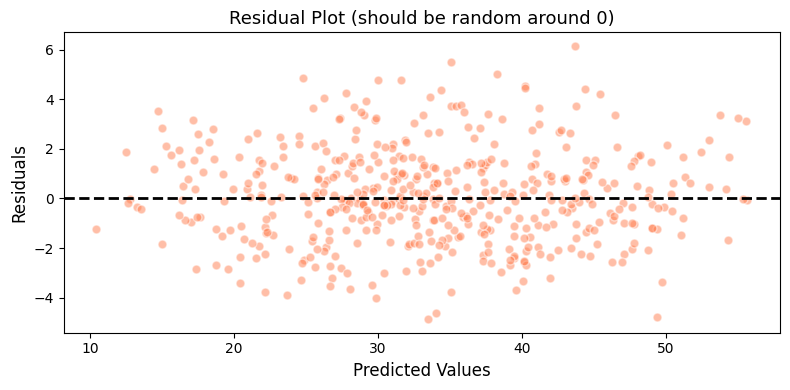

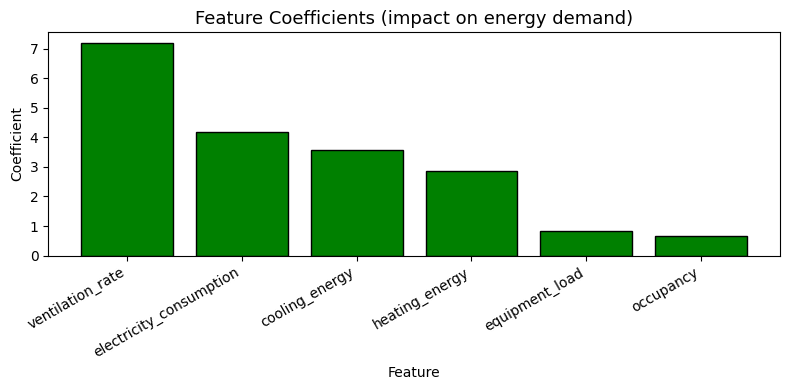

In [31]:
# Plot 1 — Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='white', s=40)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Energy Demand", fontsize=12)
plt.ylabel("Predicted Energy Demand", fontsize=12)
plt.title(f"Actual vs Predicted  |  R² = {r2:.4f}", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 2 — Residuals
residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.5, color='coral', edgecolors='white', s=40)
plt.axhline(0, color='black', linestyle='--', lw=2)
plt.xlabel("Predicted Values", fontsize=12)
plt.ylabel("Residuals", fontsize=12)
plt.title("Residual Plot (should be random around 0)", fontsize=13)
plt.tight_layout()
plt.show()

# Plot 3 — Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': top_features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8, 4))
colors = ['green' if c > 0 else 'red' for c in coef_df['Coefficient']]
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.title("Feature Coefficients (impact on energy demand)", fontsize=13)
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Justification of Feature Selection

Features were selected based on Pearson correlation analysis with the
target variable 'predicted_energy_demand'. The top 6 features with the
highest absolute correlation were chosen.

From building energy domain knowledge:
- Temperature: directly drives heating/cooling load
- Humidity: affects HVAC system demand
- Occupancy: more occupants = more lighting, plug loads, and HVAC
- HVAC/lighting energy: sub-components of total energy demand
- Solar radiation: passive heat gain affects cooling needs

## Discussion of Results

- R² = X.XX → the model explains XX% of variance in energy demand
- RMSE = X.XX → average prediction error in energy units
- The Actual vs Predicted plot shows [tight/scattered] clustering around
  the diagonal, indicating [good/moderate] linear fit
- The residual plot shows [random/patterned] distribution, suggesting
  the linear assumption [holds/may need review]
- Green bars (positive coefficients) increase energy demand;
  red bars (negative) reduce it